# Decomposição viés-variância

**Tema:** Avaliação e Validação de Modelos › Viés, Variância e Curvas de Aprendizado

Este módulo não tem `teoria.pdf`: a teoria mora aqui, ao lado do código
que a demonstra. Neste notebook construímos a decomposição do erro
esperado em viés², variância e ruído, medimos cada parcela por
simulação (o único jeito de medir, porque as parcelas dependem de
"todas as amostras de treino possíveis"), vemos a curva em U aparecer
quando a complexidade cresce, e usamos a decomposição para explicar por
que bagging e regularização funcionam.

## Por que este módulo existe

O tema 4 usou a frase "trade-off viés-variância" para justificar a
regularização, o `k` do k-NN, a poda de árvores e o bagging. Sempre com
a promessa de que a construção formal viria no tema 6. É aqui.

A pergunta que a decomposição responde é de diagnóstico: **o meu modelo
erra porque é simples demais ou porque é sensível demais aos dados?** As
duas doenças têm remédios opostos. Para a primeira (viés), mais dados
não ajudam; é preciso um modelo mais flexível ou features melhores. Para
a segunda (variância), mais dados ajudam muito, e regularizar ou agregar
também. Errar o diagnóstico custa meses: uma equipe que compra dados
rotulados para curar um problema de viés joga dinheiro fora.

**Analogia.** Um arqueiro atira dez flechas no alvo. Se todas caem
agrupadas, mas longe do centro, o problema é de mira: **viés**. Ajustar a
mira resolve; atirar mais flechas, não. Se caem espalhadas ao redor do
centro, o problema é de pulso: **variância**. A média das dez flechas
está no centro; cada flecha individual, não. Em aprendizado de máquina,
cada "flecha" é o modelo que sairia de uma amostra de treino diferente,
e o "centro" é a função que de fato gera os dados.

### O que você vai conseguir fazer ao final

- Escrever a decomposição do erro quadrático esperado e explicar cada
  parcela.
- Medir viés² e variância de um algoritmo por simulação.
- Ler a curva em U e localizar um modelo nela.
- Explicar, em termos de viés e variância, o que fazem `k` do k-NN,
  `alpha` da ridge, a profundidade de uma árvore e o bagging.
- Saber o que muda quando a perda é 0-1 (classificação) em vez de
  quadrática.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import BaggingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeRegressor

rng = np.random.default_rng(641)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR, CINZA = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100", "#5A5A5A"
print("pronto")

pronto


## 1. A decomposição

Suponha que os dados vêm de $y = f(x) + \varepsilon$, com $\varepsilon$
um ruído de média zero e variância $\sigma^2$ que ninguém consegue
prever (o preço de um imóvel depende de coisas que não estão na base).
Um algoritmo recebe uma amostra de treino $D$ e devolve um modelo
$\hat{f}_D$. Amostras diferentes dão modelos diferentes, então
$\hat{f}_D(x)$ é uma variável aleatória: **a distribuição das flechas**.

Para um ponto fixo $x$, o erro quadrático esperado sobre amostras de
treino e sobre o ruído se decompõe em três parcelas:

$$\mathbb{E}\big[(y - \hat{f}_D(x))^2\big] = \underbrace{\big(f(x) - \mathbb{E}[\hat{f}_D(x)]\big)^2}_{\text{viés}^2} + \underbrace{\mathbb{E}\big[(\hat{f}_D(x) - \mathbb{E}[\hat{f}_D(x)])^2\big]}_{\text{variância}} + \underbrace{\sigma^2}_{\text{ruído}}$$

- **Viés²**: a distância entre a *média* dos modelos e a verdade. Mede o
  que o algoritmo não consegue representar nem com dados infinitos.
- **Variância**: quanto o modelo muda de uma amostra de treino para
  outra. Mede a sensibilidade ao acaso da amostra.
- **Ruído** ($\sigma^2$): o erro que a melhor previsão possível ainda
  comete. Não depende do algoritmo; é o **piso**.

A demonstração cabe em três linhas. Chame $\bar{f}(x) = \mathbb{E}[\hat{f}_D(x)]$.
Some e subtraia $\bar{f}$ e $f$ dentro do quadrado:
$y - \hat{f}_D = \varepsilon + (f - \bar{f}) + (\bar{f} - \hat{f}_D)$. Ao
elevar ao quadrado e tomar a esperança, os três produtos cruzados somem
($\varepsilon$ tem média zero e é independente de $D$; $\bar{f} - \hat{f}_D$
tem média zero por definição de $\bar{f}$). Sobram os três quadrados.

Duas consequências que costumam passar despercebidas:

1. A decomposição é de um **algoritmo** (o procedimento que vai de
   amostra a modelo), não de um modelo específico. "O viés do meu
   modelo" é uma frase sem sentido; "o viés da ridge com
   $\alpha = 10$ neste problema" faz sentido.
2. Nenhuma das parcelas é observável com **uma** amostra. Você tem uma
   flecha; viés e variância falam da distribuição das flechas. Por isso
   a única forma de medi-las é simular muitas amostras de treino, o que
   exige conhecer $f$. Em dados reais não conhecemos $f$; usamos a
   decomposição como **lente**, e as curvas de aprendizado (próximo
   notebook) como o instrumento de medição possível.

## 2. Medindo por simulação

Um problema onde conhecemos a verdade: $f(x) = \sin(2\pi x)$ mais uma
rampa, ruído gaussiano com $\sigma = 0{,}3$. Sorteamos muitas amostras
de treino, ajustamos o mesmo algoritmo em cada uma e, numa grade de
pontos $x$, olhamos a nuvem de previsões.

Os parâmetros abaixo estão expostos de propósito. Depois de ler o
notebook, mude `SIGMA`, `N_TREINO` e os graus e rode de novo.

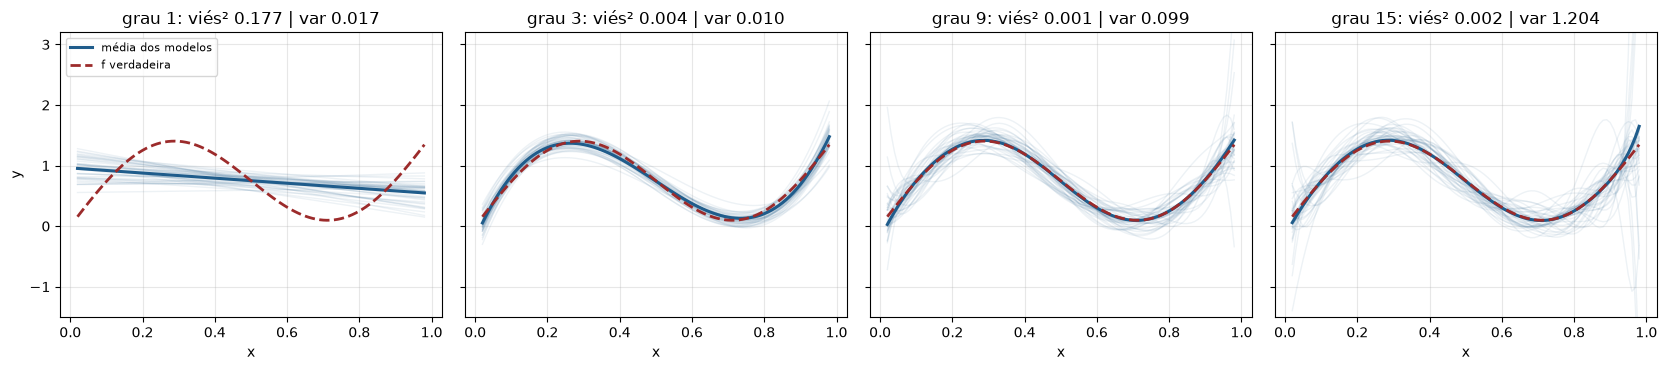

In [2]:
SIGMA = 0.3            # desvio do ruído: o piso do erro é SIGMA**2
N_TREINO = 40          # tamanho de cada amostra de treino
N_AMOSTRAS = 300       # quantas amostras de treino sorteamos ("flechas")
GRAUS = [1, 3, 9, 15]  # graus do polinômio que vamos comparar

def f_verdadeira(x):
    return np.sin(2 * np.pi * x) + 1.5 * x

def amostra(n, semente):
    g = np.random.default_rng(semente)
    x = np.sort(g.random(n))
    return x, f_verdadeira(x) + g.normal(0, SIGMA, n)

def polinomio(grau):
    return make_pipeline(PolynomialFeatures(grau), StandardScaler(), LinearRegression())

x_grade = np.linspace(0.02, 0.98, 97)
f_grade = f_verdadeira(x_grade)

def previsoes_em_grade(fabrica_modelo, n_treino=N_TREINO, n_amostras=N_AMOSTRAS):
    """Uma linha por amostra de treino, uma coluna por ponto da grade."""
    P = np.empty((n_amostras, len(x_grade)))
    for s in range(n_amostras):
        x, y = amostra(n_treino, s)
        P[s] = fabrica_modelo().fit(x[:, None], y).predict(x_grade[:, None])
    return P

def decompoe(P):
    """Viés², variância e ruído médios sobre a grade, mais o erro total esperado."""
    media = P.mean(axis=0)
    vies2 = np.mean((f_grade - media) ** 2)
    variancia = np.mean(P.var(axis=0))
    return {"viés²": vies2, "variância": variancia, "ruído": SIGMA ** 2,
            "erro esperado": vies2 + variancia + SIGMA ** 2}

fig, axes = plt.subplots(1, len(GRAUS), figsize=(4.2 * len(GRAUS), 3.8), sharey=True)
for ax, grau in zip(axes, GRAUS):
    P = previsoes_em_grade(lambda: polinomio(grau))
    for linha in P[:40]:
        ax.plot(x_grade, linha, color=AZUL, alpha=0.08, lw=1)
    ax.plot(x_grade, P.mean(axis=0), color=AZUL, lw=2.2, label="média dos modelos")
    ax.plot(x_grade, f_grade, color=VERMELHO, lw=2, ls="--", label="f verdadeira")
    d = decompoe(P)
    ax.set_title(f"grau {grau}: viés² {d['viés²']:.3f} | var {d['variância']:.3f}")
    ax.set_ylim(-1.5, 3.2); ax.set_xlabel("x")
axes[0].set_ylabel("y"); axes[0].legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

**Leitura esperada:** com grau 1, as 40 retas ficam quase em cima uma da
outra (variância mínima), mas a média delas passa longe da senoide
(viés alto): o arqueiro de pulso firme e mira torta. Com grau 15, a
média acompanha a senoide (viés quase zero), mas cada modelo individual
oscila de um jeito diferente, principalmente nas bordas, onde há menos
pontos: pulso trêmulo. O grau 3 já acerta a forma com variância mínima;
o 9 tem viés ainda menor, mas paga por ele dez vezes mais variância.

## 3. A curva em U

Repetimos a simulação para todos os graus de 1 a 15 e empilhamos as
parcelas. É a figura mais reproduzida da área, e vale a pena vê-la
nascer dos números em vez de decorá-la.

       viés²  variância  ruído  erro esperado
grau                                         
1     0.1769     0.0167   0.09         0.2837
2     0.1758     0.0335   0.09         0.2993
3     0.0036     0.0099   0.09         0.1035
4     0.0034     0.0142   0.09         0.1077
5     0.0001     0.0167   0.09         0.1068
6     0.0001     0.0258   0.09         0.1159
7     0.0002     0.0480   0.09         0.1382
8     0.0003     0.0590   0.09         0.1493
9     0.0006     0.0993   0.09         0.1899
10    0.0004     0.1160   0.09         0.2064
11    0.0005     0.1806   0.09         0.2711
12    0.0006     0.2422   0.09         0.3327
13    0.0015     0.4046   0.09         0.4961
14    0.0009     0.6844   0.09         0.7753
15    0.0020     1.2040   0.09         1.2960


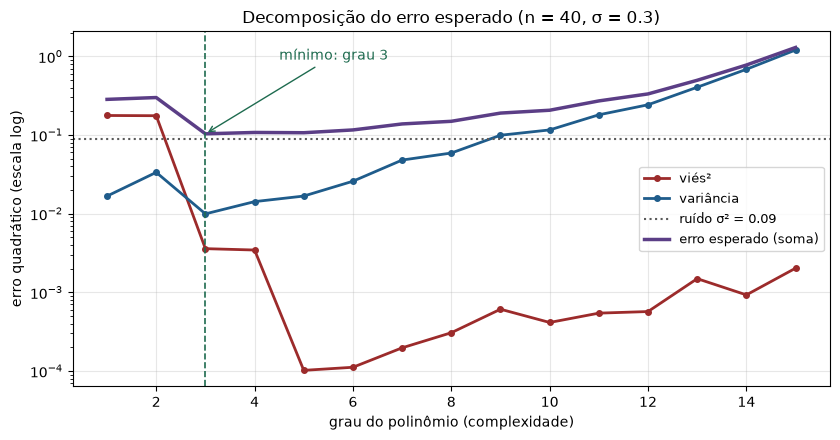

In [3]:
graus = np.arange(1, 16)
tabela = pd.DataFrame([decompoe(previsoes_em_grade(lambda g=g: polinomio(g))) for g in graus],
                      index=graus)
tabela.index.name = "grau"
print(tabela.round(4).to_string())

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(graus, tabela["viés²"], color=VERMELHO, lw=2, marker="o", ms=4, label="viés²")
ax.plot(graus, tabela["variância"], color=AZUL, lw=2, marker="o", ms=4, label="variância")
ax.axhline(SIGMA ** 2, color=CINZA, lw=1.5, ls=":", label=f"ruído σ² = {SIGMA**2:.2f}")
ax.plot(graus, tabela["erro esperado"], color=ROXO, lw=2.5, label="erro esperado (soma)")
melhor = tabela["erro esperado"].idxmin()
ax.axvline(melhor, color=VERDE, lw=1.2, ls="--")
ax.annotate(f"mínimo: grau {melhor}", (melhor, tabela.loc[melhor, "erro esperado"]),
            xytext=(melhor + 1.5, tabela["erro esperado"].max() * 0.7), color=VERDE,
            arrowprops=dict(arrowstyle="->", color=VERDE))
ax.set_yscale("log"); ax.set_xlabel("grau do polinômio (complexidade)")
ax.set_ylabel("erro quadrático (escala log)"); ax.legend(fontsize=9)
ax.set_title(f"Decomposição do erro esperado (n = {N_TREINO}, σ = {SIGMA})")
plt.tight_layout(); plt.show()

Três coisas para reparar:

- O viés² cai rápido e depois **para de cair**: no grau 3 já é pequeno,
  a partir do 5 é praticamente zero. O polinômio representa a senoide;
  mais graus não compram nada.
- A variância **sobe sem parar**. Cada grau é um coeficiente a mais para
  o ruído puxar.
- O ruído é uma reta horizontal que nenhuma escolha de grau move. Se
  alguém prometer um erro abaixo de $\sigma^2 = 0{,}09$ neste problema,
  está prometendo prever o imprevisível.

O mínimo do erro esperado fica onde a queda do viés² e a subida da
variância se equilibram. Repare que o ponto ótimo **não** é onde o viés
é zero: aceitar um pouco de viés em troca de muita variância é a
essência da regularização, e é exatamente o que o tema 4 chamou de
trade-off.

**Mude `N_TREINO` para 400 e rode de novo.** O mínimo se move para a
direita: com mais dados, a variância de cada grau cai, e um modelo mais
complexo passa a compensar. Complexidade ótima não é uma propriedade do
algoritmo; é uma propriedade do par algoritmo + tamanho da amostra.

## 4. O exemplo numérico num único ponto

A decomposição vale ponto a ponto. Vamos olhar $x = 0{,}5$ com o
polinômio de grau 9 e conferir as contas na mão.

In [4]:
x0 = 0.5
i0 = np.argmin(np.abs(x_grade - x0))
P9 = previsoes_em_grade(lambda: polinomio(9))
flechas = P9[:, i0]                                  # as 300 previsões em x0
media_flechas = flechas.mean()
vies2_x0 = (f_verdadeira(x0) - media_flechas) ** 2
var_x0 = flechas.var()
# o erro esperado "de verdade" em x0: para cada flecha, muitos sorteios do ruído de y
y0 = f_verdadeira(x0) + rng.normal(0, SIGMA, (2000, len(flechas)))
erro_medido = np.mean((y0 - flechas) ** 2)
print(f"f({x0}) = {f_verdadeira(x0):.4f} | média das {len(flechas)} previsões = {media_flechas:.4f}")
print(f"viés²     = ({f_verdadeira(x0):.4f} - {media_flechas:.4f})² = {vies2_x0:.5f}")
print(f"variância = {var_x0:.5f}")
print(f"ruído     = {SIGMA ** 2:.5f}")
print(f"soma      = {vies2_x0 + var_x0 + SIGMA ** 2:.5f}   |   erro quadrático medido = {erro_medido:.5f}")

f(0.5) = 0.7500 | média das 300 previsões = 0.7397
viés²     = (0.7500 - 0.7397)² = 0.00011
variância = 0.01647
ruído     = 0.09000
soma      = 0.10658   |   erro quadrático medido = 0.10639


A soma e o erro medido diferem só pelo ruído de simulação. Repare na
proporção: em $x = 0{,}5$, com grau 9 e 40 pontos, o viés² é
desprezível e a variância é uma fração do ruído. O erro deste algoritmo
aqui está a um passo do piso. Nas bordas ($x$ perto de 0 ou 1) a
variância é muito maior; troque `x0` e veja.

## 5. A mesma lente sobre k-NN, ridge e árvores

O grau do polinômio é um botão de complexidade explícito. Outros
algoritmos têm o seu, às vezes ao contrário: em k-NN, complexidade
**cai** com $k$; em ridge, complexidade **cai** com $\alpha$.

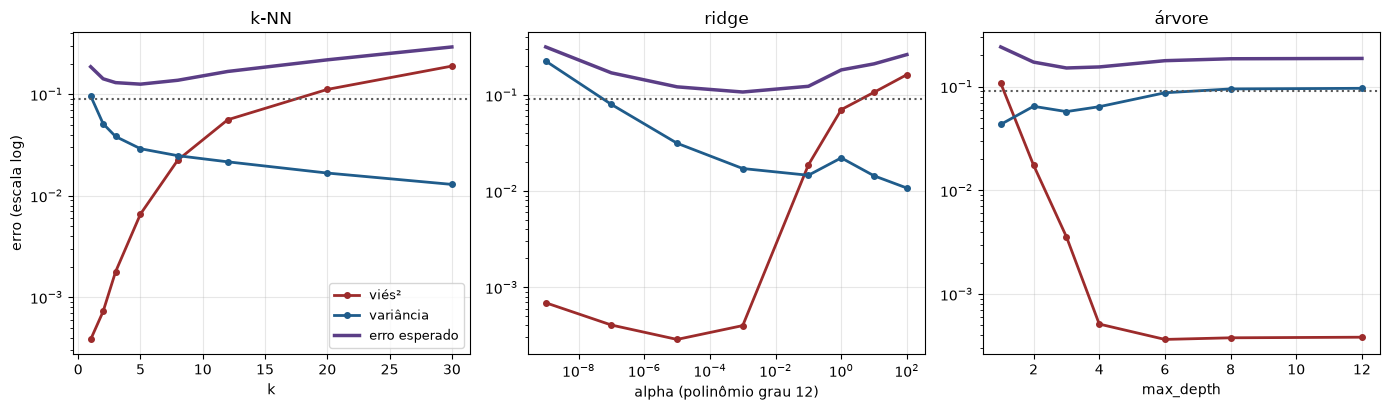

                           k: mínimo em 5 (viés² 0.0066, variância 0.0290)
   alpha (polinômio grau 12): mínimo em 0.001 (viés² 0.0004, variância 0.0172)
                   max_depth: mínimo em 3 (viés² 0.0036, variância 0.0573)


In [5]:
def curva(fabrica, valores, rotulo):
    linhas = [decompoe(previsoes_em_grade(lambda v=v: fabrica(v))) for v in valores]
    return pd.DataFrame(linhas, index=pd.Index(valores, name=rotulo))

ks = [1, 2, 3, 5, 8, 12, 20, 30]
alphas = [1e-9, 1e-7, 1e-5, 1e-3, 1e-1, 1, 10, 100]
profundidades = [1, 2, 3, 4, 6, 8, 12]
t_knn = curva(lambda k: KNeighborsRegressor(k), ks, "k")
t_ridge = curva(lambda a: make_pipeline(PolynomialFeatures(12), StandardScaler(), Ridge(alpha=a)),
                alphas, "alpha (polinômio grau 12)")
t_arv = curva(lambda d: DecisionTreeRegressor(max_depth=d, random_state=0), profundidades,
              "max_depth")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, t, titulo in zip(axes, [t_knn, t_ridge, t_arv], ["k-NN", "ridge", "árvore"]):
    ax.plot(t.index, t["viés²"], color=VERMELHO, marker="o", ms=4, lw=2, label="viés²")
    ax.plot(t.index, t["variância"], color=AZUL, marker="o", ms=4, lw=2, label="variância")
    ax.plot(t.index, t["erro esperado"], color=ROXO, lw=2.5, label="erro esperado")
    ax.axhline(SIGMA ** 2, color=CINZA, ls=":", lw=1.5)
    ax.set_xlabel(t.index.name); ax.set_title(titulo); ax.set_yscale("log")
    if titulo == "ridge":
        ax.set_xscale("log")
axes[0].set_ylabel("erro (escala log)"); axes[0].legend(fontsize=9)
plt.tight_layout(); plt.show()

for t in (t_knn, t_ridge, t_arv):
    m = t["erro esperado"].idxmin()
    print(f"{t.index.name:>28s}: mínimo em {m} (viés² {t.loc[m, 'viés²']:.4f}, "
          f"variância {t.loc[m, 'variância']:.4f})")

**Leitura esperada:** os três painéis são a mesma curva em U lida em
direções diferentes. Em k-NN, $k = 1$ é o extremo de variância (o
modelo copia o ruído do vizinho mais próximo); $k = 30$ com 40 pontos é
quase a média global, viés puro. Na ridge, $\alpha$ pequeno devolve o
polinômio de grau 12 sem freio; $\alpha$ grande achata tudo. Na árvore, a
profundidade 1 é um degrau (viés enorme) e a 12 memoriza os 40 pontos.

É por isso que o tema 4 pôde tratar `k`, `alpha`, `max_depth` e
`min_samples_leaf` como o mesmo tipo de decisão: todos regulam onde o
algoritmo se senta na curva em U.

## 6. Bagging: variância cai, viés fica

O bagging (tema 4, módulo 7) treina o mesmo algoritmo em reamostras
bootstrap e tira a média. A média de $B$ variáveis aleatórias com a
mesma média tem **a mesma média** (o viés não muda) e variância menor
(tanto menor quanto menos correlacionadas forem). A decomposição prevê
exatamente o que a simulação deveria mostrar: uma árvore profunda é um
algoritmo de viés baixo e variância alta, o candidato ideal.

In [6]:
arvore_funda = lambda: DecisionTreeRegressor(max_depth=None, min_samples_leaf=1, random_state=0)
ensacada = lambda B: BaggingRegressor(DecisionTreeRegressor(min_samples_leaf=1), n_estimators=B,
                                     random_state=0)
linhas = [{"modelo": "árvore sem poda", **decompoe(previsoes_em_grade(arvore_funda))}]
for B in [5, 25, 100]:
    linhas.append({"modelo": f"bagging de {B} árvores", **decompoe(previsoes_em_grade(lambda B=B: ensacada(B)))})
print(pd.DataFrame(linhas).set_index("modelo").round(4).to_string())

                         viés²  variância  ruído  erro esperado
modelo                                                         
árvore sem poda         0.0004     0.0961   0.09         0.1865
bagging de 5 árvores    0.0005     0.0578   0.09         0.1482
bagging de 25 árvores   0.0006     0.0492   0.09         0.1398
bagging de 100 árvores  0.0009     0.0467   0.09         0.1376


O viés² fica praticamente parado; a variância despenca e o erro esperado
vai atrás. É também o motivo de o bagging **não** salvar um modelo de
viés alto: ensacar 100 retas dá uma reta. Boosting, por contraste,
ataca o viés (cada árvore corrige o resíduo da anterior) e por isso pode
sobreajustar se rodar demais, como o módulo 8 do tema 4 mostrou.

## 7. O que muda em classificação

Para a perda 0-1 a decomposição aditiva não vale. Domingos (2000)
mostrou uma versão em que a variância pode entrar com sinal **negativo**:
quando a previsão majoritária está errada num ponto (viés naquele
ponto), instabilidade entre modelos às vezes acerta por acaso, e
variância "ajuda". Na prática a intuição sobrevive (modelos simples
sofrem de viés, modelos flexíveis de variância), mas as parcelas não se
somam como em regressão, e uma medida de "variância de um
classificador" precisa dizer qual definição usa.

Um atalho útil: trabalhe com a **probabilidade** prevista e a perda
quadrática sobre ela (o Brier score, módulo 5 deste tema). Aí a
decomposição volta a valer, e o "ruído" passa a ser a incerteza
irredutível $p(1-p)$ de cada ponto: mesmo o classificador perfeito erra
30% das vezes num ponto em que $p = 0{,}3$.

## 8. Em produção: o piso que ninguém vê

A parcela que mais causa discussão numa empresa é a que não aparece em
nenhum gráfico de tuning: o ruído. Alguns cenários em que ele decide:

- **Meta impossível.** Uma equipe de crédito recebe a meta de "AUC
  0,90". Se a informação disponível no momento da decisão só permite
  0,82 (o resto é comportamento futuro que nenhuma feature captura), a
  equipe vai passar meses trocando de algoritmo. A decomposição diz onde
  olhar: se um modelo flexível e um regularizado empatam e as curvas de
  aprendizado (próximo notebook) estão planas, o que sobra é piso. O
  remédio é dado novo (uma fonte de informação que não existia), não
  modelo novo.
- **Estimando o piso.** Quando a base tem observações repetidas com o
  mesmo $x$ (o mesmo produto vendido em dias parecidos, o mesmo cliente
  avaliado várias vezes), a variância de $y$ dentro desses grupos é uma
  estimativa direta de $\sigma^2$. Vale calcular antes de prometer
  qualquer erro.
- **Rotulagem humana.** Em problemas rotulados por pessoas (fraude
  confirmada por analista, diagnóstico por imagem), a taxa de
  discordância entre dois rotuladores é um piso prático: o modelo não
  vai concordar com o rótulo mais do que os próprios rotuladores
  concordam entre si.

## O que levar deste notebook

- Erro esperado = viés² + variância + ruído, para a perda quadrática,
  ponto a ponto, sobre a distribuição de amostras de treino.
- Viés e variância são propriedades de um **algoritmo** num problema,
  não de um modelo; só se medem por simulação.
- Complexidade compra viés com variância; o ótimo depende do tamanho
  da amostra e nunca fica no viés zero.
- Bagging reduz variância sem tocar no viés; boosting e mais
  flexibilidade reduzem viés à custa de variância.
- O ruído é o piso. Antes de prometer uma métrica, estime-o.

→ Próximo: **Curvas de aprendizado e diagnóstico**, o instrumento de
medição que funciona sem conhecer $f$.